# Tutorial 16 - add_soh

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
segmented_data = eet.add_primitive_segments(
    df=standardized_data,
    config=eet.PrimitiveConfig.DEFAULT,
)

In [5]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=None, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=1, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: add_soh

In [6]:
data_with_soh = eet.add_soh(
    df=standardized_data,
    neware_bool=True,
    df_primitives=segmented_data,
    config=eet.BatteryConfig.DEFAULT,
    verbose=True,
)

In [7]:
added_cols = [c for c in data_with_soh.columns if c not in standardized_data.columns]
added_cols

['Capacity[Ah]', 'SOH']

<Axes: xlabel='Test_Time[s]'>

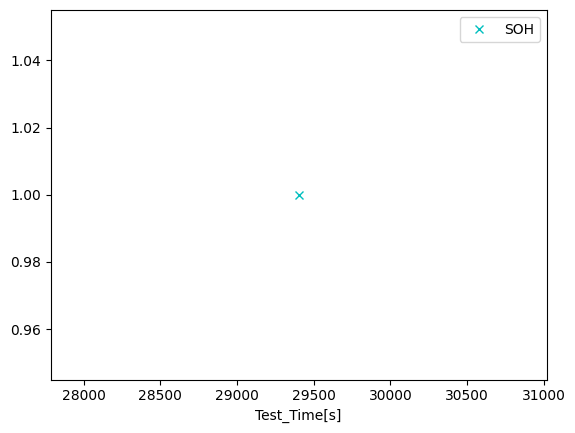

In [8]:
data_with_soh.plot(x="Test_Time[s]", y="SOH", style="cx")